In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Attribute table overview

Load the LiDAR attribute table and take a first look at its contents.

In [2]:
from pathlib import Path

import pandas as pd

In [ ]:
# Find the repository root whether Jupyter starts there or in a subfolder.
current_directory = Path.cwd().resolve()
project_root = next(
    folder
    for folder in [current_directory, *current_directory.parents]
    if (folder / "README.md").exists() and (folder / "legacy_code").exists()
)

data_path = (
    project_root
    / "legacy_code"
    / "data"
    / "LiDAR_Years_All_29thjune"
    / "LiDAR_Years_All_attributes.csv"
)
data_path

In [4]:
attribute_table = pd.read_csv(data_path, low_memory=False)

In [5]:
attribute_table.shape

(1152801, 23)

In [6]:
attribute_table.head()

,CanopyCover,GapFraction,LAI,elev_percentile_95th,AOI,LiDAR_year,block,identification,SPIS_RF,code,...,display_id,spis,plyr,yldc,next_thin_,last_thinn,area,Age,Top_Height,Vol
0,0.032258,0.967742,0.015664,7.974448,Aberfoyle,2002,21,750,NaN,NaN,...,701 21 1148 B,NaN,0,0,0,0,428.531661,2002,8.771893,0.161024
1,0.106187,0.893813,0.053628,11.241876,Aberfoyle,2002,21,752,NaN,NaN,...,701 21 1148 B,NaN,0,0,0,0,515.907833,2002,12.366064,1.221036
2,0.014235,0.985765,0.006849,9.210998,Aberfoyle,2002,21,753,NaN,NaN,...,701 21 1148 B,NaN,0,0,0,0,523.195196,2002,10.132098,0.115010
3,0.006928,0.993072,0.003321,2.212976,Aberfoyle,2002,21,755,NaN,NaN,...,701 21 1148 B,NaN,0,0,0,0,595.336727,2002,2.434274,-0.006095
4,0.106942,0.893058,0.054032,5.895068,Aberfoyle,2002,21,757,NaN,NaN,...,701 21 1148 B,NaN,0,0,0,0,256.810161,2002,6.484575,0.164049


## Data exploration plan

### 1. Basic data checks

- [ ] Check the number of rows and columns
- [ ] Check the data type of each column
- [ ] Count missing values and calculate the percentage missing
- [ ] Check whether missing values follow a pattern
- [ ] Check for fully duplicated rows
- [ ] Check for duplicated IDs or repeated observations

### 2. Understand the data

- [ ] Find out what each column means and what its units are
- [ ] Group columns by type, such as LiDAR, forest, location, and ID columns
- [ ] Calculate summary statistics for numerical columns
- [ ] Count the unique values in category columns
- [ ] Check which years and forest areas are included
- [ ] Work out what one row represents

### 3. Explore values and distributions

- [ ] Plot histograms for the main numerical variables
- [ ] Plot bar charts for important categories
- [ ] Use box plots to find possible outliers
- [ ] Look more closely at unusual or impossible values

### 4. Compare variables

- [ ] Check correlations between numerical variables
- [ ] Create scatter plots for important relationships
- [ ] Compare results between years, areas, and forest groups
- [ ] Look for changes over time where the same places were measured again

### 5. Explore the spatial data

- [ ] Check the coordinate system and geometry type
- [ ] Check for missing, empty, or invalid geometries
- [ ] Map the overall study area and data coverage
- [ ] Map coverage for each LiDAR year
- [ ] Map important variables such as canopy cover, LAI, height, and volume
- [ ] Map missing values and unusual values to see whether they form spatial patterns

### 6. Record what we learn

- [ ] Write down the main findings after each section
- [ ] Record any data problems and questions
- [ ] Decide which questions need their own analysis notebook

# 1. Basic data checks

The aim of these checks is to find simple problems before we analyse the data. We will check the table size, column types, missing values, and duplicates. These checks do not change the data.

## 1.1 Dataset size and structure

First, we check how large the table is and what kind of values each column stores.

In [ ]:
# Aim: check the table size, column types, and survey years.
print(f"Rows: {attribute_table.shape[0]:,}")
print(f"Columns: {attribute_table.shape[1]}")
print(f"LiDAR years: {sorted(attribute_table['LiDAR_year'].unique())}")

attribute_table.dtypes.to_frame(name="data_type")

**Result:** The table contains **1,152,801 rows and 23 columns**. It contains numerical measurements, text categories, six LiDAR years (2002, 2006, 2008, 2012, 2021, 2023) and 339,956 different plot IDs.

**Follow-up:** Confirm the meaning and units of the less obvious fields, especially `LAI`, `Vol`, `area`, `plyr`, `yldc`, and the thinning fields.

## 1.2 Missing values

The aim is to find which columns have gaps. Missing values are not removed at this stage.

In [ ]:
# Aim: find missing information and check the linked species fields.
missing_summary = pd.DataFrame({
    "missing_rows": attribute_table.isna().sum(),
    "missing_percentage": attribute_table.isna().mean().mul(100).round(2),
}).query("missing_rows > 0")

a = attribute_table["spis"].isna()
b = attribute_table["yldc"].eq(0)
spis_yldc_check = pd.Series({
    "both missing spis and zero yldc": (a & b).sum(),
    "missing spis only": (a & ~b).sum(),
    "zero yldc only": (~a & b).sum(),
})

missing_spis_by_year = (
    attribute_table.groupby("LiDAR_year")["spis"]
    .agg(total_rows="size", missing_spis=lambda values: values.isna().sum())
)

print("Columns containing missing values")
display(missing_summary)
print("Relationship between spis and yldc")
display(spis_yldc_check.to_frame(name="rows"))
print("Missing spis by year")
missing_spis_by_year

**Result:** Only `SPIS_RF`, `code`, and `spis` contain missing values. Each is missing in about 24% of rows. All other columns are complete.

**Note:** `SPIS_RF` and `code` are outputs from Miguel’s random forest classification of dominant species. Their missing values are expected and can be ignored in this general overview. Keep the rows; do not remove them because these two values are missing.

**Follow-up:** What does a missing `spis` value mean? Is it a non-forest plot, unknown species, or a plot that did not match the sub-compartment database?

Therefore, missing spis and yldc = 0 occur in exactly the same rows. This suggests a shared cause, such as no matched sub-compartment database record. -- how do i check this

## 1.3 Exact duplicate rows

This check looks for rows where every value is exactly the same.

In [13]:
# Aim: find rows that are exactly the same in every column.
# Exact copies may be accidental, so we count them before doing any analysis.
number_of_full_duplicates = attribute_table.duplicated().sum()

print(f"Fully duplicated rows: {number_of_full_duplicates:,}")

Fully duplicated rows: 0


**Result:** There are **no fully duplicated rows**. The repeated plot IDs investigated below are therefore not exact copies; at least one value differs.

## 1.4 Plot IDs through time

Each `identification` value represents a 20 m × 20 m plot. An ID appearing in different years is expected because the same plot can be measured again.

In [14]:
# Aim: check whether the same ID appears more than once.
# A repeated ID is not always a mistake. It may mean that the same place
# was measured in more than one year, so we also check ID and year together.
id_column = "identification"
id_counts = attribute_table[id_column].value_counts(dropna=False)

number_of_unique_ids = attribute_table[id_column].nunique(dropna=True)
number_of_repeated_ids = (id_counts > 1).sum()
# Count extra rows where the same plot ID and LiDAR year have already appeared.
repeated_id_and_year_rows = attribute_table.duplicated(
    subset=[id_column, "LiDAR_year"]).sum() # The first row in each plot/year group is not counted as a duplicate.

print(f"Unique IDs: {number_of_unique_ids:,}")
print(f"IDs that appear more than once: {number_of_repeated_ids:,}")
print(f"Repeated ID and year combinations: {repeated_id_and_year_rows:,}")

Unique IDs: 339,956
IDs that appear more than once: 321,771
Repeated ID and year combinations: 3,849


**Result:** There are **339,956 unique plot IDs**, and most appear in more than one year. This is expected for repeat surveys.

There are also **3,849 ID/year combinations that appear twice within the same year**. These are the records that need closer investigation.

In [15]:
# Aim: count plots and repeated ID/year pairs in each year.
id_year_counts = (
    attribute_table
    .groupby(["LiDAR_year", "identification"])
    .size()
)

year_summary = (
    attribute_table
    .groupby("LiDAR_year")
    .agg(
        number_of_rows=("identification", "size"),
        number_of_unique_ids=("identification", "nunique"),
    )
)

year_summary["repeated_id_year_pairs"] = (
    id_year_counts.gt(1)
    .groupby(level="LiDAR_year")
    .sum()
)

# Every repeated ID/year group contains two rows.
year_summary["rows_in_repeated_pairs"] = (
    year_summary["repeated_id_year_pairs"] * 2
)

year_summary["percentage_of_rows_in_pairs"] = (
    year_summary["rows_in_repeated_pairs"]
    .div(year_summary["number_of_rows"])
    .mul(100)
    .round(2)
)

year_summary

,number_of_rows,number_of_unique_ids,repeated_id_year_pairs,rows_in_repeated_pairs,percentage_of_rows_in_pairs
LiDAR_year,,,,,
2002,54857,54692,165,330,0.60
2006,32745,32663,82,164,0.50
2008,183098,182520,578,1156,0.63
2012,264432,263576,856,1712,0.65
2021,304560,303496,1064,2128,0.70
2023,313109,312005,1104,2208,0.71


**Result:** Every repeated ID/year combination appears exactly twice. There are **7,698 affected rows** in total. Repeated pairs occur in every year, but they account for only about **0.5–0.7% of rows** in each year.

The raw number increases in later years partly because those datasets contain more plots.

In [17]:
# Aim: compare each survey year with the survey before it.
#
# Retained = present in both years.
# Added = absent from the previous year but present in the current year.
# Dropped = present in the previous year but absent from the current year.

years = sorted(attribute_table["LiDAR_year"].unique())

ids_by_year = {
    year: set(
        attribute_table.loc[
            attribute_table["LiDAR_year"] == year,
            "identification",]) for year in years}

year_changes = []

for previous_year, current_year in zip(years[:-1], years[1:]):# E.g. 2002 with 2006, then 2006 with 2008.
    previous_ids = ids_by_year[previous_year]
    current_ids = ids_by_year[current_year]

    retained_ids = previous_ids & current_ids
    added_ids = current_ids - previous_ids
    dropped_ids = previous_ids - current_ids

    year_changes.append({
        "previous_year": previous_year,
        "current_year": current_year,
        "retained_ids": len(retained_ids),
        "added_ids": len(added_ids),
        "dropped_ids": len(dropped_ids),
        "retained_percentage": round(
            len(retained_ids) / len(previous_ids) * 100, 2
        ),
    })

year_changes = pd.DataFrame(year_changes)
year_changes

,previous_year,current_year,retained_ids,added_ids,dropped_ids,retained_percentage
0,2002,2006,28723,3940,25969,52.52
1,2006,2008,31575,150945,1088,96.67
2,2008,2012,173217,90359,9303,94.90
3,2012,2021,237438,66058,26138,90.08
4,2021,2023,296518,15487,6978,97.70


**Result:** Plot coverage changes between surveys. The largest increase is from 2006 to 2008, when 150,945 IDs appear that were not present in 2006. Retention is above 90% for most later comparisons, but only 52.52% from 2002 to 2006.

“Added” and “dropped” only describe whether an ID is present in two neighbouring surveys. They do not prove that a physical plot was created or removed.

**Note:** As mapped survey area changed between years, especially between 2002, 2006, and 2008.


In [18]:
# Aim: show how many columns differ for every repeated plot and year.
repeated_id_years = (
    id_year_counts[id_year_counts > 1]
    .rename("rows_for_id_and_year")
    .reset_index()
)

repeated_rows = attribute_table.merge(
    repeated_id_years,
    on=["LiDAR_year", "identification"],
    how="inner",
)

key_columns = ["LiDAR_year", "identification"]
columns_to_compare = [
    column
    for column in attribute_table.columns
    if column not in key_columns
]

# True means that a column has different values across the two rows.
differences_by_plot = (
    repeated_rows
    .groupby(key_columns)[columns_to_compare]
    .nunique(dropna=False)
    .gt(1)
)

repeated_plot_summary = (
    differences_by_plot
    .sum(axis=1)
    .rename("number_of_columns_that_differ")
    .reset_index()
)

repeated_plot_summary["columns_that_differ"] = (
    differences_by_plot
    .apply(
        lambda row: ", ".join(row.index[row].tolist()),
        axis=1,
    )
    .values
)

# Show the first ten repeated plots.
display(repeated_plot_summary.head(10))

# Show how common each number of differences is.
display(
    repeated_plot_summary["number_of_columns_that_differ"]
    .value_counts()
    .sort_index()
    .rename_axis("number_of_columns_that_differ")
    .reset_index(name="number_of_repeated_plot_years")
)

,LiDAR_year,identification,number_of_columns_that_differ,columns_that_differ
0,2002,868,6,"CanopyCover, GapFraction, LAI, elev_percentile..."
1,2002,12646,6,"CanopyCover, GapFraction, LAI, elev_percentile..."
2,2002,18015,6,"CanopyCover, GapFraction, LAI, elev_percentile..."
3,2002,21489,6,"CanopyCover, GapFraction, LAI, elev_percentile..."
4,2002,28523,6,"CanopyCover, GapFraction, LAI, elev_percentile..."
5,2002,35818,6,"CanopyCover, GapFraction, LAI, elev_percentile..."
6,2002,42307,6,"CanopyCover, GapFraction, LAI, elev_percentile..."
7,2002,42344,6,"CanopyCover, GapFraction, LAI, elev_percentile..."
8,2002,42914,6,"CanopyCover, GapFraction, LAI, elev_percentile..."
9,2002,43028,6,"CanopyCover, GapFraction, LAI, elev_percentile..."


,number_of_columns_that_differ,number_of_repeated_plot_years
0,3,1
1,4,1
2,6,3835
3,7,12


**Note:** The table above summarises every repeated plot/year pair. Each pair contains two rows, and the six differing columns are the LiDAR measurements. This confirms that these records are not exact duplicates.

## 1.5 Values recorded as zero

Some forestry columns contain many zeros. The aim is to check whether zero is a real value or a way of recording missing information.

In [34]:
# Aim: count meaningful zero values without treating them as ordinary missing data.

zero_columns = ["plyr", "yldc", "next_thin_", "last_thinn"]
zero_flags = attribute_table[zero_columns].eq(0)

zero_summary = pd.DataFrame({
    "zero_rows": zero_flags.sum(),
    "zero_percentage": zero_flags.mean().mul(100).round(2),
})

print(f"Rows with at least one of these zeros: {zero_flags.any(axis=1).sum():,}")
print(f"Percentage with at least one zero: {zero_flags.any(axis=1).mean() * 100:.2f}%")
display(zero_summary)

# Check the numerical columns that were not included above.
measurement_columns = [
    "CanopyCover", "GapFraction", "LAI",
    "elev_percentile_95th", "Top_Height", "Vol",
]
measurement_zero_check = pd.DataFrame({
    "minimum_value": attribute_table[measurement_columns].min(),
    "exact_zero_rows": attribute_table[measurement_columns].eq(0).sum(),
})

# A zero identifier would be invalid, so check for it separately.
identifier_columns = ["identification", "block", "blk", "cpmt"]
identifier_zero_check = pd.DataFrame({
    "minimum_value": attribute_table[identifier_columns].min(),
    "zero_rows": attribute_table[identifier_columns].eq(0).sum(),
})

# Text and classification columns use missing-value checks, not zero checks.
category_columns = [
    "AOI", "display_id", "scpt", "spis",
    "code", "SPIS_RF",
]
category_missing_check = (
    attribute_table[category_columns].isna().sum().to_frame("missing_rows")
)

# Check area, survey year, and calculated age using suitable rules.
other_column_checks = pd.Series({
    "area at or below zero": attribute_table["area"].le(0).sum(),
    "LiDAR year at or below zero": attribute_table["LiDAR_year"].le(0).sum(),
    "negative Age": attribute_table["Age"].lt(0).sum(),
    "Age over 200": attribute_table["Age"].gt(200).sum(),
    "Age formula disagreements": (
        attribute_table["Age"]
        != attribute_table["LiDAR_year"] - attribute_table["plyr"]
    ).sum(),
}, name="rows")

print("LiDAR measurement checks")
display(measurement_zero_check)
print("Identifier checks")
display(identifier_zero_check)
print("Text and classification missing-value checks")
display(category_missing_check)
print("Area, survey year, and age checks")
other_column_checks.to_frame()

Rows with at least one of these zeros: 972,856
Percentage with at least one zero: 84.39%


,zero_rows,zero_percentage
plyr,275635,23.91
yldc,275935,23.94
next_thin_,249992,21.69
last_thinn,970743,84.21


LiDAR measurement checks


,minimum_value,exact_zero_rows
CanopyCover,0.000148,0
GapFraction,0.000000,2860
LAI,0.000000,284
elev_percentile_95th,2.037485,0
Top_Height,2.241234,0
Vol,-0.543163,0


Identifier checks


,minimum_value,zero_rows
identification,1,0
block,21,0
blk,21,0
cpmt,1,0


Text and classification missing-value checks


,missing_rows
AOI,0
display_id,0
scpt,0
spis,275935
code,276209
SPIS_RF,276209


Area, survey year, and age checks


,rows
area at or below zero,0
LiDAR year at or below zero,0
negative Age,72633
Age over 200,278844
Age formula disagreements,0


**Note** 
- LiDAR measurements (`CanopyCover, GapFraction, LAI, elev_percentile_95th, Top_Height, Vol`) zero or near zero can be genuine measurements.
- Identifiers (`identification, block, blk, cpmt`): zero would be checked as an invalid identifier, not as missing forestry information.
- Text/category columns (`AOI, display_id, scpt, spis, code`): these cannot meaningfully be tested with .eq(0); missing text is checked using .isna()
- area: zero would mean invalid geometry; all recorded areas are positive.
- Age: it is calculated from LiDAR_year - plyr, so its problems are checked through negative or unrealistic ages rather than zero alone.

**Result:** Zero appears in 23.91% of `plyr`, 23.94% of `yldc`, 21.69% of `next_thin_`, and 84.21% of `last_thinn` records.

**Interpretation:** These zeros do not all mean the same thing. `last_thinn = 0` means never thinned, and `next_thin_ = 0` means no thinning is planned. `plyr = 0` means a usable planting year is unavailable, while `yldc = 0` occurs in exactly the same rows as missing `spis`. Keep these states separate rather than replacing or deleting every zero.

## 1.6 Numerical ranges and possible unusual values

This check looks at the smallest, typical, and largest values. The flagged values are not automatically errors; they are values that need an explanation.

In [21]:
# Summarise the range of the main numerical variables.
range_columns = ["Age", "Top_Height", "Vol", "LAI", "area"]

range_summary = (
    attribute_table[range_columns]
    .quantile([0, 0.01, 0.5, 0.99, 1])
    .T
)
range_summary.columns = [
    "minimum", "1st_percentile", "median",
    "99th_percentile", "maximum",
]
display(range_summary)

# Count values that may need checking.
possible_issues = pd.Series({
    "negative Age": attribute_table["Age"].lt(0).sum(),
    "Age over 200": attribute_table["Age"].gt(200).sum(),
    "Top_Height over 100": attribute_table["Top_Height"].gt(100).sum(),
    "negative Vol": attribute_table["Vol"].lt(0).sum(),
    "Vol over 1000": attribute_table["Vol"].gt(1000).sum(),
    "area not equal to 400": (~np.isclose(attribute_table["area"], 400)).sum(),
}, name="number_of_rows")

possible_issues

,minimum,1st_percentile,median,99th_percentile,maximum
Age,-24.000000,-13.000000,45.000000,2023.000000,2023.000000
Top_Height,2.241234,2.745964,16.051456,40.325283,461.432142
Vol,-0.543163,-0.002828,8.548248,69.854724,2322.148468
LAI,0.000000,0.001643,0.553614,10.461717,23.025801
area,250.003305,274.986256,400.000000,1042.734941,1585.856476


negative Age              72633
Age over 200             278844
Top_Height over 100           9
negative Vol              53403
Vol over 1000                 5
area not equal to 400    345391
Name: number_of_rows, dtype: int64

**Results:** There are 72,633 negative ages, 53,403 negative volume values, nine heights above 150 m, five volumes above 1,000, and 345,391 areas that are not exactly 400 m².

**Interpretation:** Negative ages identify scans taken before the stand recorded in the 2025 sub-compartment database was planted. Ages above 200 occur when `plyr = 0`, so they are not real tree ages. Non-400 m² areas are expected for reshaped boundary cells and should be retained.

The extreme heights require spatial or raw-LiDAR checking. Most negative volumes are close to zero, but the volume formula and units still need confirmation. Section 1.10 separately checks the unusually high 2021 LAI range.

## 1.7 Calculated and repeated columns

This check finds columns that contain the same information or are calculated from one another. This matters because later models should not treat copies as separate evidence.

In [22]:
# Count rows that do not follow the expected relationships.
relationship_checks = pd.Series({
    "CanopyCover + GapFraction is not 1": (
        (attribute_table["CanopyCover"]
         + attribute_table["GapFraction"] - 1).abs() > 0.00001
    ).sum(),
    "Top_Height is not 1.1 times elevation percentile": (
        (attribute_table["Top_Height"]
         - 1.1 * attribute_table["elev_percentile_95th"]).abs() > 0.00001
    ).sum(),
    "Age is not LiDAR year minus planting year": (
        attribute_table["Age"]
        != attribute_table["LiDAR_year"] - attribute_table["plyr"]
    ).sum(),
    "block and blk are different": (
        attribute_table["block"] != attribute_table["blk"]
    ).sum(),
}, name="number_of_rows")

relationship_checks

CanopyCover + GapFraction is not 1                   0
Top_Height is not 1.1 times elevation percentile     0
Age is not LiDAR year minus planting year            0
block and blk are different                         16
Name: number_of_rows, dtype: int64

**Results:** `CanopyCover + GapFraction` equals 1, `Top_Height` is exactly 1.1 × `elev_percentile_95th`, and `Age` is always `LiDAR_year - plyr`. The `block` and `blk` columns disagree in only 16 rows.

**Interpretation:** When `plyr` is zero, the age calculation returns the LiDAR year rather than a tree age; use an unavailable age for these rows in later analysis. Avoid including both members of a calculated pair in the same model. `blk` matches the block part of `display_id`, but the meaning of `block` should still be confirmed for the 16 disagreements.

## 1.8 Record flags needing different treatment

These flags separate unresolved measurement problems from valid historical or spatial context. They are labels for review; no rows are removed.

In [ ]:
# Aim: create each review flag once and reuse it.
review_flags = pd.DataFrame({
    "extra repeated plot/year row": attribute_table.duplicated(
        ["LiDAR_year", "identification"], keep="first"
    ),
    "Top_Height over 150": attribute_table["Top_Height"].gt(150),
    "negative Vol": attribute_table["Vol"].lt(0),
    "Vol over 1000": attribute_table["Vol"].gt(1000),
    "block and blk differ": attribute_table["block"].ne(attribute_table["blk"]),
})

context_flags = pd.DataFrame({
    "survey before planting": attribute_table["Age"].lt(0),
    "planting year unavailable": attribute_table["plyr"].eq(0),
    "species unavailable": attribute_table["spis"].isna(),
    "irregular boundary area": ~np.isclose(attribute_table["area"], 400),
})

flag_summary = pd.concat({
    "needs review": review_flags.sum(),
    "valid context": context_flags.sum(),
}, axis=1).fillna(0).astype(int)

# Check whether negative volume mainly occurs where vegetation is very low.
low_vegetation = (
    attribute_table["CanopyCover"].lt(0.10)
    & attribute_table["LAI"].lt(0.20)
    & attribute_table["Top_Height"].lt(5)
)
negative_volume = review_flags["negative Vol"]

negative_volume_check = pd.Series({
    "negative volume rows": negative_volume.sum(),
    "also low vegetation": (negative_volume & low_vegetation).sum(),
    "percentage also low vegetation": round(
        (negative_volume & low_vegetation).sum() / negative_volume.sum() * 100, 2
    ),
})

display(flag_summary)
negative_volume_check.to_frame(name="value")

**Interpretation:**

- Repeated plot/year rows, extreme height or volume, and block disagreements require investigation.
- Pre-planting scans, unavailable planting/species information, and irregular boundary areas describe context. They are not automatic errors.
- Almost all negative volumes occur with a very low vegetation signal. They may be near-zero model outputs, but the volume formula still needs confirmation.
- Keep these flags as separate columns so later decisions remain transparent.

## 1.9 Shrinkage between LiDAR scans

A plot may have a lower measured height in a later scan. This could represent harvesting, storm or pest damage, poor growth, a changed plot ID, or measurement noise. It is therefore a **change flag**, not automatically an error.

For this first check, repeated plot/year measurements are averaged so that each plot has one value per year. This is provisional and should be repeated after the duplicate-measurement issue is resolved.

In [27]:
# Create one provisional record for each plot and year.
change_variables = ["Top_Height", "CanopyCover", "LAI", "Vol"]

plot_year_values = (
    attribute_table
    .groupby(["identification", "LiDAR_year"], as_index=False)[change_variables]
    .mean()
    .sort_values(["identification", "LiDAR_year"])
)

plot_groups = plot_year_values.groupby("identification", sort=False)
plot_year_values["previous_year"] = plot_groups["LiDAR_year"].shift()
plot_year_values["years_between_scans"] = (
    plot_year_values["LiDAR_year"] - plot_year_values["previous_year"]
)

# Calculate the change from the previous available scan of the same plot.
for variable in change_variables:
    plot_year_values[f"{variable}_change"] = (
        plot_year_values[variable] - plot_groups[variable].shift()
    )

plot_changes = plot_year_values.loc[
    plot_year_values["previous_year"].notna()
].copy()

print(f"Plot-to-scan comparisons: {len(plot_changes):,}")
print(f"Plots with at least two scans: {plot_changes['identification'].nunique():,}")

Plot-to-scan comparisons: 808,996
Plots with at least two scans: 321,756


In [28]:
# Count height decreases using several sizes of drop.
height_drop_limits = {
    "any measured decrease": 0,
    "drop greater than 1 m": 1,
    "drop greater than 2 m": 2,
    "drop greater than 5 m": 5,
    "drop greater than 10 m": 10,
}

shrinkage_summary = pd.DataFrame({
    label: {
        "comparison_intervals": (
            plot_changes["Top_Height_change"] < -limit
        ).sum(),
        "percentage_of_intervals": round(
            (plot_changes["Top_Height_change"] < -limit).mean() * 100, 2
        ),
        "unique_plots": plot_changes.loc[
            plot_changes["Top_Height_change"] < -limit,
            "identification",
        ].nunique(),
    }
    for label, limit in height_drop_limits.items()
}).T

shrinkage_summary

,comparison_intervals,percentage_of_intervals,unique_plots
any measured decrease,120750.0,14.93,94449.0
drop greater than 1 m,64175.0,7.93,57951.0
drop greater than 2 m,52967.0,6.55,49659.0
drop greater than 5 m,42573.0,5.26,41457.0
drop greater than 10 m,35279.0,4.36,35070.0


In [29]:
# Check which scan transitions contain the most height decreases.
shrinkage_by_transition = (
    plot_changes
    .groupby(["previous_year", "LiDAR_year"])
    .agg(
        comparisons=("identification", "size"),
        height_decreases=("Top_Height_change", lambda values: values.lt(0).sum()),
        drops_over_2m=("Top_Height_change", lambda values: values.lt(-2).sum()),
        median_height_change=("Top_Height_change", "median"),
    )
    .reset_index()
)

shrinkage_by_transition["height_decrease_percentage"] = (
    shrinkage_by_transition["height_decreases"]
    .div(shrinkage_by_transition["comparisons"])
    .mul(100)
    .round(2)
)

shrinkage_by_transition

,previous_year,LiDAR_year,comparisons,height_decreases,drops_over_2m,median_height_change,height_decrease_percentage
0,2002.0,2006,28723,2647,718,1.794487,9.22
1,2002.0,2008,22333,5715,1915,1.379144,25.59
2,2002.0,2012,1231,1124,1077,-23.261092,91.31
3,2002.0,2021,2313,2191,2160,-19.742616,94.73
4,2002.0,2023,52,47,44,-12.758282,90.38
5,2006.0,2008,31575,7315,497,0.671376,23.17
6,2006.0,2012,388,183,84,0.062601,47.16
7,2006.0,2021,650,494,449,-13.383444,76.00
8,2006.0,2023,16,9,6,-0.265934,56.25
9,2008.0,2012,173217,17127,6022,1.872628,9.89


In [30]:
# Check whether height drops over 2 m are supported by other measurements.
large_height_drop = plot_changes["Top_Height_change"].lt(-2)
number_of_large_drops = large_height_drop.sum()

supporting_signals = pd.Series({
    "also lower CanopyCover": (
        large_height_drop & plot_changes["CanopyCover_change"].lt(0)
    ).sum(),
    "also lower LAI": (
        large_height_drop & plot_changes["LAI_change"].lt(0)
    ).sum(),
    "also lower Vol": (
        large_height_drop & plot_changes["Vol_change"].lt(0)
    ).sum(),
}, name="number_of_intervals")

supporting_signal_summary = pd.DataFrame({
    "number_of_intervals": supporting_signals,
    "percentage_of_large_height_drops": (
        supporting_signals.div(number_of_large_drops).mul(100).round(2)
    ),
})

supporting_signal_summary

,number_of_intervals,percentage_of_large_height_drops
also lower CanopyCover,43537,82.20
also lower LAI,40286,76.06
also lower Vol,48256,91.11


**Results:**

- There are **808,996 comparisons** between successive available scans of 321,756 plots.
- Height decreases in **120,750 intervals (14.93%)**, affecting 94,449 plots.
- Height falls by more than 2 m in **52,967 intervals (6.55%)**, affecting 49,659 plots.
- Height falls by more than 5 m in **42,573 intervals (5.26%)**.
- Among drops over 2 m, 91.11% also have lower volume, 82.20% have lower canopy cover, and 76.06% have lower raw LAI.

**Interpretation:** A small negative change may be measurement noise. A large decline supported by lower canopy and volume may record clear-felling, storm or pest damage, mortality, or another real structural change. Large declines without supporting signals are stronger candidates for measurement or matching errors. Section 1.11 shows that 2021 LAI is on a different scale, so LAI changes involving that year cannot yet support this interpretation.

Some comparisons skip intermediate survey years because the plot was not present in every scan. Several of these groups have very high decline rates. This may represent harvesting and replanting, but it could also show that plot IDs or joined sub-compartment records are not stable through time.

**Possible resolution:**

- Do not remove all shrinking plots; they may contain the main evidence needed to explain growth problems.
- Treat small declines separately from large declines and confirm a sensible noise threshold with a LiDAR expert.
- Map large declines and compare them with clear-felling, thinning, storm, pest, soil, weather, and topographic information.
- Inspect large declines that are not supported by canopy, LAI, or volume changes.
- Repeat this analysis after resolving same-year duplicate measurements.

**Follow-up questions:**

- What decrease in `Top_Height` is larger than expected LiDAR measurement error?
- Are management, clear-felling, storm, pest, or mortality records available for the large-decline plots?
- Are plot IDs and sub-compartment joins stable when a plot disappears and later returns in the dataset?

## 1.10 Is LAI calculated consistently between years?

This check asks whether `LAI` has the same scale and relationship with `GapFraction` in every survey. A change in the calculation method could look like a real forest change.

In [ ]:
# Aim: compare the LAI scale and formula between survey years.
expected_lai = (
    0.477724
    * -np.log(attribute_table["GapFraction"].clip(lower=1e-12))
).clip(upper=5.5)

lai_consistency = (
    attribute_table
    .assign(
        does_not_match=(attribute_table["LAI"] - expected_lai).abs().gt(0.01)
    )
    .groupby("LiDAR_year")
    .agg(
        rows=("LAI", "size"),
        median_LAI=("LAI", "median"),
        maximum_LAI=("LAI", "max"),
        rows_not_matching=("does_not_match", "sum"),
    )
)

lai_consistency

**Result:** The same simple relationship reproduces `LAI` to within 0.01 for every row in 2002, 2006, 2008, 2012, and 2023. It does not reproduce 285,354 of the 304,560 rows from 2021.

The maximum is 5.5 in every year except 2021, where it reaches 23.03. This is strong evidence that 2021 used a different LAI calculation or input. Raw LAI changes involving 2021 should not be interpreted until the processing method is confirmed. Because `LAI` is calculated from gap fraction in the other years, it is not independent supporting evidence for canopy change.

## Basic-check summary

### Confirmed structure

- The table has **1,152,801 rows**, **23 columns**, and six LiDAR years.
- Only `spis`, `SPIS_RF`, and `code` contain missing values. Missing `SPIS_RF` and `code` values are expected classification gaps.
- There are no exact duplicate rows, but **3,849 plot/year pairs** occur twice with different LiDAR values.
- Plot coverage changes between years, especially from 2006 to 2008.
- Resolving only the extra repeated rows would retain **99.67%** of the data. However, the two measurements can differ substantially, so one should not be selected randomly.

### Values that are unusual but not automatically errors

- Negative ages are expected when a stand recorded in the 2025 sub-compartment database was planted after an earlier LiDAR survey. They identify a pre-planting observation rather than a negative biological age.
- When `plyr = 0`, the calculated `Age` is not a real tree age and should be treated as unavailable in later analysis.
- `last_thinn = 0` means never thinned, and `next_thin_ = 0` means no thinning is planned. These are meaningful states, not ordinary missing values.
- Non-400 m² areas are expected near sub-compartment boundaries because cells were merged or reshaped to avoid contamination from neighbouring stands. They should not be removed.
- Most negative volumes are very close to zero and occur where the vegetation signal is low. The volume formula still needs to be confirmed before deciding whether to keep, recode, or exclude them.
- Height decreases occur in **14.93%** of scan intervals, and **6.55%** fall by more than 2 m. These are possible disturbance or management outcomes, not automatic errors.

### Confirmed or likely data problems

- The repeated plot/year measurements are linked to irregular boundary cells and misplaced centroids. A corrected-centroid dataset should be obtained before resolving them.
- Nine heights exceed 150 m and five associated volumes exceed 1,000. These are likely LiDAR artefacts and should be checked spatially or against raw LiDAR before exclusion.
- `block` and `blk` disagree in 16 rows. `blk` agrees with the block component of `display_id`, but the meaning of `block` still needs confirmation.
- The 2021 `LAI` values use a different scale or calculation. **285,354 of 304,560** rows do not follow the relationship found in every other year. Raw LAI change involving 2021 is therefore not comparable yet. --- check the distribution for this variable in the next section

### Important implications for later analysis

- `GapFraction`, `LAI`, `Top_Height`, and `Age` are calculated from other columns. Calculated copies should not be treated as independent evidence in the same model.
- The 2025 sub-compartment attributes were attached to every historical survey. Species, planting year, yield class, and management fields must therefore be interpreted relative to each LiDAR date.
- Survey intervals have different lengths, and some plot comparisons skip surveys. Growth changes should eventually be annualised using exact acquisition dates.
- Removing every row containing a zero in the four forestry fields would discard about **84%** of the data and would erase meaningful management states.

### Remaining decisions before cleaning

- Obtain the corrected-centroid data and decide how repeated plot/year records should be resolved.
- Confirm the `LAI` and `Vol` formulas, units, caps, and any year-specific processing differences.
- Inspect the small number of extreme-height locations using their geometry and raw LiDAR where possible.
- Confirm whether `blk` is the authoritative block field.
- Define a defensible height-change threshold using expected LiDAR uncertainty.
- Link large declines to thinning, clear-felling, storms, pests, disease, drought, and other disturbance records rather than deleting them.

# Remaining follow-up questions

1. Can the corrected-centroid data resolve the repeated plot/year measurements?
2. What are the exact formulas, units, and processing rules for `LAI` and `Vol`, including the different 2021 LAI scale?
3. Can the extreme-height locations be checked against geometry and raw LiDAR?
4. Is `blk` the authoritative block field?
5. What height decrease is larger than expected LiDAR measurement uncertainty?
6. Which thinning, clear-felling, storm, pest, disease, drought, and mortality records are available?
7. What exact acquisition dates should be used to annualise change between scans?

# 2. Understanding the data

Section 1 already counted the survey years, rows, plot IDs, missing values, and repeated plot/year records. This section does not calculate those results again. It focuses on what the columns mean, how they are grouped, what one row represents, and how to work with one survey year at a time.

## 2.1 Column meanings, units, and groups

`Needs confirmation` is used where the dataset alone cannot prove the exact definition or unit. These entries should be checked against the processing documentation or with the data provider.

In [35]:
# Create a simple data dictionary for all 23 columns.
column_dictionary = pd.DataFrame({
    "column": [
        "CanopyCover", "GapFraction", "LAI",
        "elev_percentile_95th", "Top_Height", "Vol",
        "AOI", "LiDAR_year", "area",
        "identification", "block", "blk", "cpmt",
        "scpt", "display_id",
        "spis", "plyr", "yldc", "next_thin_",
        "last_thinn", "Age", "SPIS_RF", "code",
    ],
    "group": [
        "LiDAR measurement", "LiDAR measurement", "LiDAR measurement",
        "LiDAR measurement", "derived LiDAR", "derived LiDAR",
        "location", "survey", "geometry",
        "ID", "location/ID", "location/ID", "location/ID",
        "location/ID", "location/ID",
        "recorded species", "sub-compartment database",
        "sub-compartment database", "management", "management",
        "derived forest", "predicted species",
        "predicted species",
    ],
    "meaning": [
        "Proportion of the cell covered by canopy",
        "Proportion of the cell without canopy",
        "Leaf area relative to ground area",
        "95th percentile of vegetation height",
        "1.1 times the 95th-percentile height",
        "Estimated timber volume metric",
        "Area of interest or forest name",
        "Year of the LiDAR survey",
        "Area of the plot geometry",
        "Stable plot or grid-cell identifier",
        "Alternative block assignment; exact source unclear",
        "Block number used in the sub-compartment ID",
        "Compartment number",
        "Sub-compartment code",
        "Combined block, compartment, and sub-compartment ID",
        "Main recorded species code from the 2025 sub-compartment database",
        "Planting year from the 2025 sub-compartment database",
        "Yield class: maximum mean annual timber volume production",
        "Planned next thinning year; zero means none planned",
        "Most recent thinning year; zero means never thinned",
        "LiDAR year minus planting year",
        "Numeric random-forest species prediction; not planned for the main analysis",
        "Text label for the random-forest species prediction; not planned for the main analysis",
    ],
    "unit_or_format": [
        "proportion from 0 to 1", "proportion from 0 to 1",
        "dimensionless (m² leaf area per m² ground)",
        "metres; confirm", "metres; confirm",
        "needs confirmation",
        "text", "calendar year", "m²",
        "integer ID", "integer code", "integer code",
        "integer code", "text code", "combined text ID",
        "text species code", "calendar year or zero",
        "class code given in multiples of 2",
        "calendar year or zero", "calendar year or zero",
        "years", "integer class 1–10", "text class",
    ],
})

# Confirm that every table column appears exactly once.
print(f"Columns documented: {len(column_dictionary)} of {attribute_table.shape[1]}")
print("Undocumented columns:", sorted(set(attribute_table.columns) - set(column_dictionary["column"])))
column_dictionary

Columns documented: 23 of 23
Undocumented columns: []


,column,group,meaning,unit_or_format
0,CanopyCover,LiDAR measurement,Proportion of the cell covered by canopy,proportion from 0 to 1
1,GapFraction,LiDAR measurement,Proportion of the cell without canopy,proportion from 0 to 1
2,LAI,LiDAR measurement,Leaf area relative to ground area,dimensionless (m² leaf area per m² ground)
3,elev_percentile_95th,LiDAR measurement,95th percentile of vegetation height,metres; confirm
4,Top_Height,derived LiDAR,1.1 times the 95th-percentile height,metres; confirm
5,Vol,derived LiDAR,Estimated timber volume metric,needs confirmation
6,AOI,location,Area of interest or forest name,text
7,LiDAR_year,survey,Year of the LiDAR survey,calendar year
8,area,geometry,Area of the plot geometry,m²
9,identification,ID,Stable plot or grid-cell identifier,integer ID


In [36]:
# Show which columns belong to each type of information.
columns_by_group = (
    column_dictionary.groupby("group")["column"]
    .agg(list)
    .to_frame("columns")
)

columns_by_group

,columns
group,
ID,[identification]
LiDAR measurement,"[CanopyCover, GapFraction, LAI, elev_percentil..."
derived LiDAR,"[Top_Height, Vol]"
derived forest,[Age]
geometry,[area]
location,[AOI]
location/ID,"[block, blk, cpmt, scpt, display_id]"
management,"[next_thin_, last_thinn]"
predicted species,"[SPIS_RF, code]"


## 2.2 What does one row represent?

One row normally represents **one LiDAR measurement record for one identified plot geometry in one survey year**. The row combines LiDAR measurements with attributes taken from the 2025 sub-compartment database.

It does not necessarily represent one independent forest stand: many plot cells belong to the same sub-compartment. It is also not always one unique plot/year observation because 3,849 plot/year pairs contain two LiDAR records. Those pairs remain unresolved.

In [37]:
# Show one row vertically so each part of the record is easy to read.
attribute_table.iloc[0].to_frame(name="first_row")

,first_row
CanopyCover,0.032258
GapFraction,0.967742
LAI,0.015664
elev_percentile_95th,7.974448
AOI,Aberfoyle
LiDAR_year,2002
block,21
identification,750
SPIS_RF,NaN
code,NaN


## 2.3 Separate DataFrames for each LiDAR year

These DataFrames keep every original row, including unresolved repeated plot/year records. Creating copies makes them easy to explore separately, but it uses additional memory. `data_by_year` is the main container; the six named variables are convenient shortcuts.

In [38]:
# Split the full table into one DataFrame for each survey year.
data_by_year = {
    year: attribute_table.loc[attribute_table["LiDAR_year"].eq(year)].copy()
    for year in sorted(attribute_table["LiDAR_year"].unique())
}

data_2002 = data_by_year[2002]
data_2006 = data_by_year[2006]
data_2008 = data_by_year[2008]
data_2012 = data_by_year[2012]
data_2021 = data_by_year[2021]
data_2023 = data_by_year[2023]

year_dataframe_summary = pd.DataFrame({
    year: {
        "rows": len(year_data),
        "columns": year_data.shape[1],
        "unique_plot_IDs": year_data["identification"].nunique(),
    }
    for year, year_data in data_by_year.items()
}).T

print("All rows retained:", year_dataframe_summary["rows"].sum() == len(attribute_table))
year_dataframe_summary

All rows retained: True


,rows,columns,unique_plot_IDs
2002,54857,23,54692
2006,32745,23,32663
2008,183098,23,182520
2012,264432,23,263576
2021,304560,23,303496
2023,313109,23,312005


## 2.4 Numerical summaries

Identifiers and category codes are numbers but are not quantities, so means and standard deviations are not useful for them. The summary below only includes measurements and forest quantities.

In [39]:
# Summarise numerical measurements without averaging ID codes.
numerical_measurement_columns = [
    "CanopyCover", "GapFraction", "LAI",
    "elev_percentile_95th", "Top_Height", "Vol",
    "area", "Age", "plyr", "yldc",
    "next_thin_", "last_thinn",
]

numerical_summary = (
    attribute_table[numerical_measurement_columns]
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
    .T
)

numerical_summary

,count,mean,std,min,1%,5%,50%,95%,99%,max
CanopyCover,1152801.0,0.532246,0.318616,0.000148,0.002160,0.009812,0.610120,0.946147,0.990397,1.000000
GapFraction,1152801.0,0.467754,0.318616,0.000000,0.009603,0.053853,0.389880,0.990188,0.997840,0.999852
LAI,1152801.0,1.252775,2.091987,0.000000,0.001643,0.006512,0.553614,5.877475,10.461717,23.025801
elev_percentile_95th,1152801.0,15.539887,9.015395,2.037485,2.496331,3.185376,14.592233,31.346917,36.659348,419.483765
Top_Height,1152801.0,17.093876,9.916935,2.241234,2.745964,3.503914,16.051456,34.481609,40.325283,461.432142
Vol,1152801.0,13.938438,16.610207,-0.543163,-0.002828,0.000459,8.548248,44.170847,69.854724,2322.148468
area,1152801.0,451.388749,142.305614,250.003305,274.986256,358.755368,400.000000,772.745407,1042.734941,1585.856476
Age,1152801.0,512.732858,843.624998,-24.000000,-13.000000,-3.000000,45.000000,2023.000000,2023.000000,2023.000000
plyr,1152801.0,1503.350940,843.359414,0.000000,0.000000,0.000000,1971.000000,2018.000000,2024.000000,2026.000000
yldc,1152801.0,9.425367,8.196829,0.000000,0.000000,0.000000,8.000000,24.000000,24.000000,24.000000


In [40]:
# Compare the LAI distribution between years because 2021 uses a different scale.
lai_summary_by_year = (
    attribute_table.groupby("LiDAR_year")["LAI"]
    .agg(
        rows="size",
        minimum="min",
        median="median",
        mean="mean",
        maximum="max",
    )
)

lai_summary_by_year

,rows,minimum,median,mean,maximum
LiDAR_year,,,,,
2002,54857,0.000720,0.624928,0.727863,5.500000
2006,32745,0.000000,0.800221,1.005112,5.500000
2008,183098,0.001157,0.394532,0.446573,5.500000
2012,264432,0.000000,0.367468,0.586636,5.500000
2021,304560,0.000290,2.257977,3.177592,23.025801
2023,313109,0.000000,0.499213,0.532404,5.500000


Task was destroyed but it is pending!
task: <Task pending name='Task-623' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/.venv/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-624' coro=<Kernel.shell_main() running at /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/.venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/shreeyagorasia/UoE_Docs/Dissertation/forest_diss/.venv/lib/python3.13/site-packages/matplotlib/transforms.py:193: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  ref = weakref.ref(
Task was destroyed but it is pending!
task: <Task pending name='Task-624' coro=<Kernel.shell_main() running at /Users/shreeyagorasia/UoE_Docs

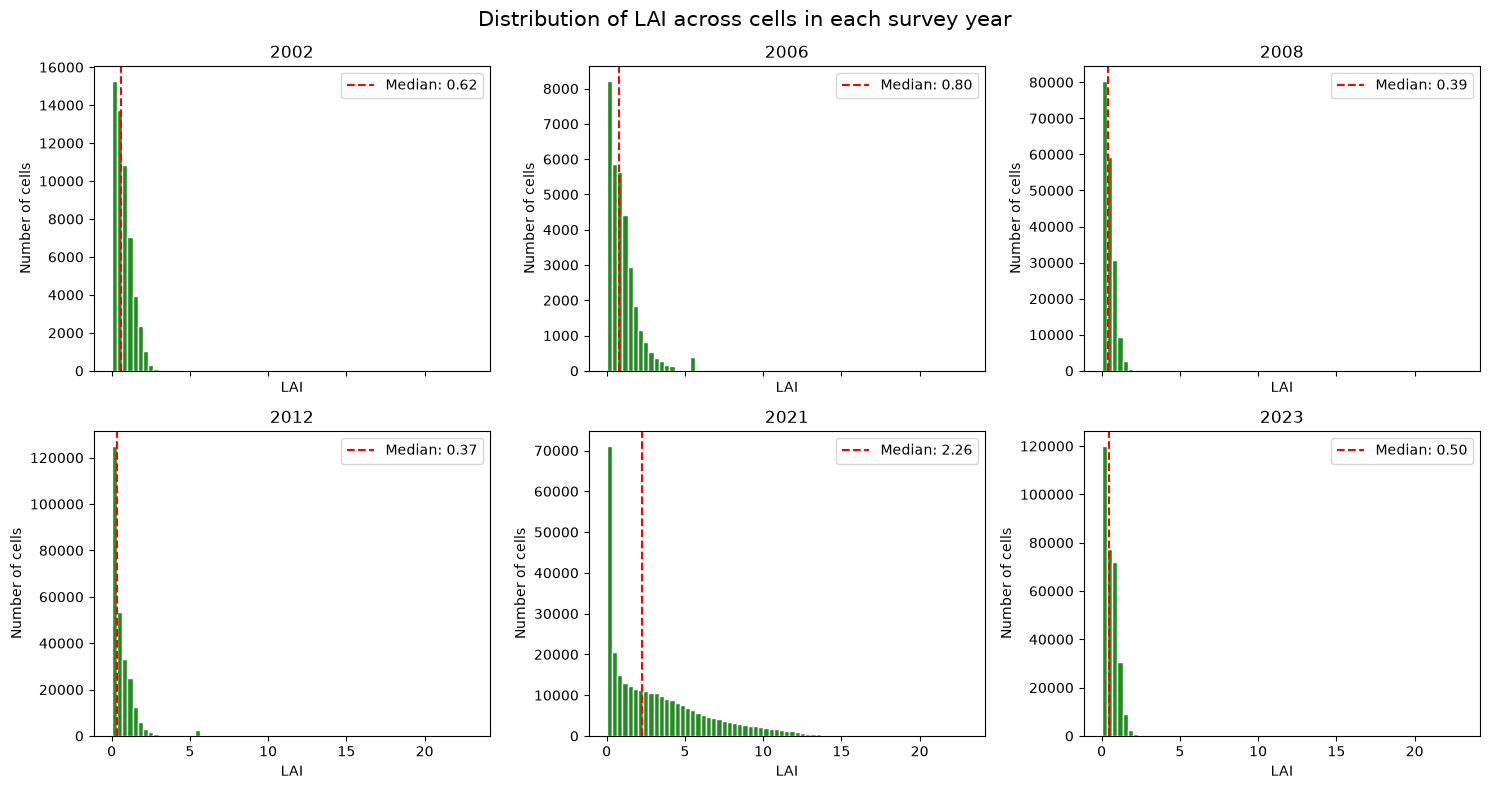

In [47]:
# Plot the LAI distribution separately for each LiDAR year.
years = sorted(attribute_table["LiDAR_year"].unique())

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 8),
    sharex=True,
    sharey=False,
)

# Use the same bins so the six distributions can be compared fairly.
lai_bins = np.linspace(0, attribute_table["LAI"].max(), 70,)

for year, axis in zip(years, axes.flat):
    year_lai = attribute_table.loc[attribute_table["LiDAR_year"] == year, "LAI", ]

    axis.hist(year_lai, bins=lai_bins, color="forestgreen", edgecolor="white",)

    axis.set_title(str(year))
    axis.set_xlabel("LAI")
    axis.set_ylabel("Number of cells")
    axis.axvline(year_lai.median(), color="red", linestyle="--", label=f"Median: {year_lai.median():.2f}",)
    axis.legend()

fig.suptitle("Distribution of LAI across cells in each survey year", fontsize=15)
plt.tight_layout()
plt.show()


## 2.5 Category values and included forest areas

This counts how many different labels each category contains. It does not calculate averages for category codes. The year counts were already calculated in Section 1.4 and are reused here.

### Section 2 notes

- The six year-specific DataFrames are copies split from the same raw table, not six independently cleaned datasets.
- All records are from the `Aberfoyle` AOI, so `AOI` cannot explain differences within this dataset.
- `identification` identifies the plot cell; `display_id` identifies the larger sub-compartment. Many plot cells can therefore share the same forest attributes.
- `spis` is the main recorded species field intended for species selection. `SPIS_RF` and `code` are prediction outputs and are not planned for the main analysis.
- Exact definitions for `Vol`, `block`, and the LiDAR height units still require confirmation.
- The 2021 LAI distribution should not be compared directly with other years until its calculation is understood.

# 3. Exploring values and distributions

Section 1 already counted known unusual values. This section evaluates the **entire unfiltered table**, including every species, age, and available survey record. However, results are not pooled across years: every distribution, category chart, box plot, outlier rule, and validity check is calculated separately for each LiDAR year.

Each investigation therefore produces six panels or six sets of results. This is more thorough and prevents a large survey year or a year-specific processing method from hiding differences. Important additional checks are survey-to-survey scale changes, category imbalance, capped or rounded values, spatial or temporal clustering of extremes, unequal cell areas, and whether the patterns remain in the final Sitka spruce cohort.

## 3.1 Histograms of the main numerical variables

Each variable gets one figure containing six year-specific histograms. The six panels use the same bins and axes so their shapes can be compared fairly. The visible range is based on the full-table 0.1st–99.9th percentiles; this changes only the plot, not the data. Percentages are used because the years contain different numbers of rows. `Age` is left out until the cohort and age rules are agreed.

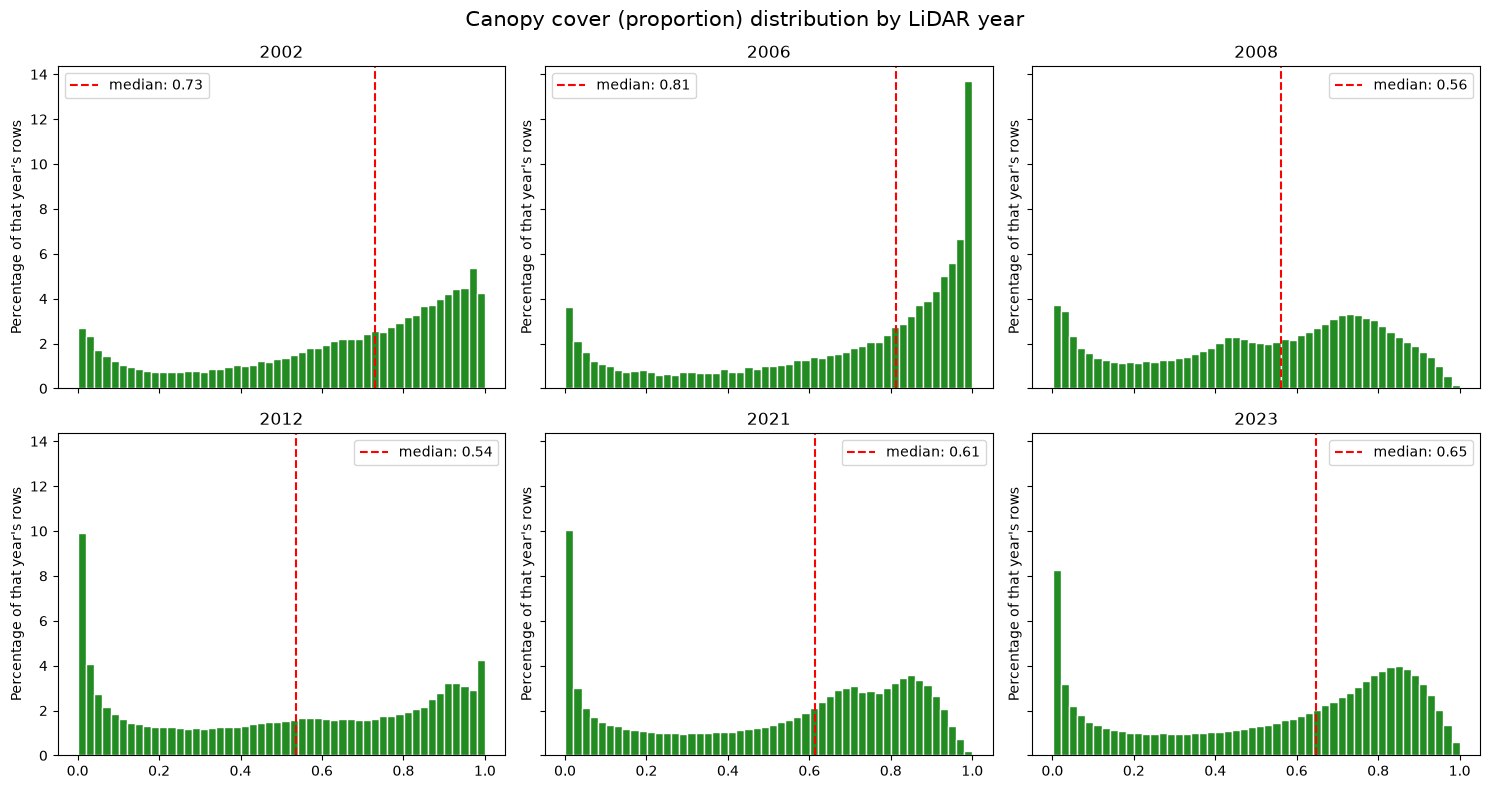

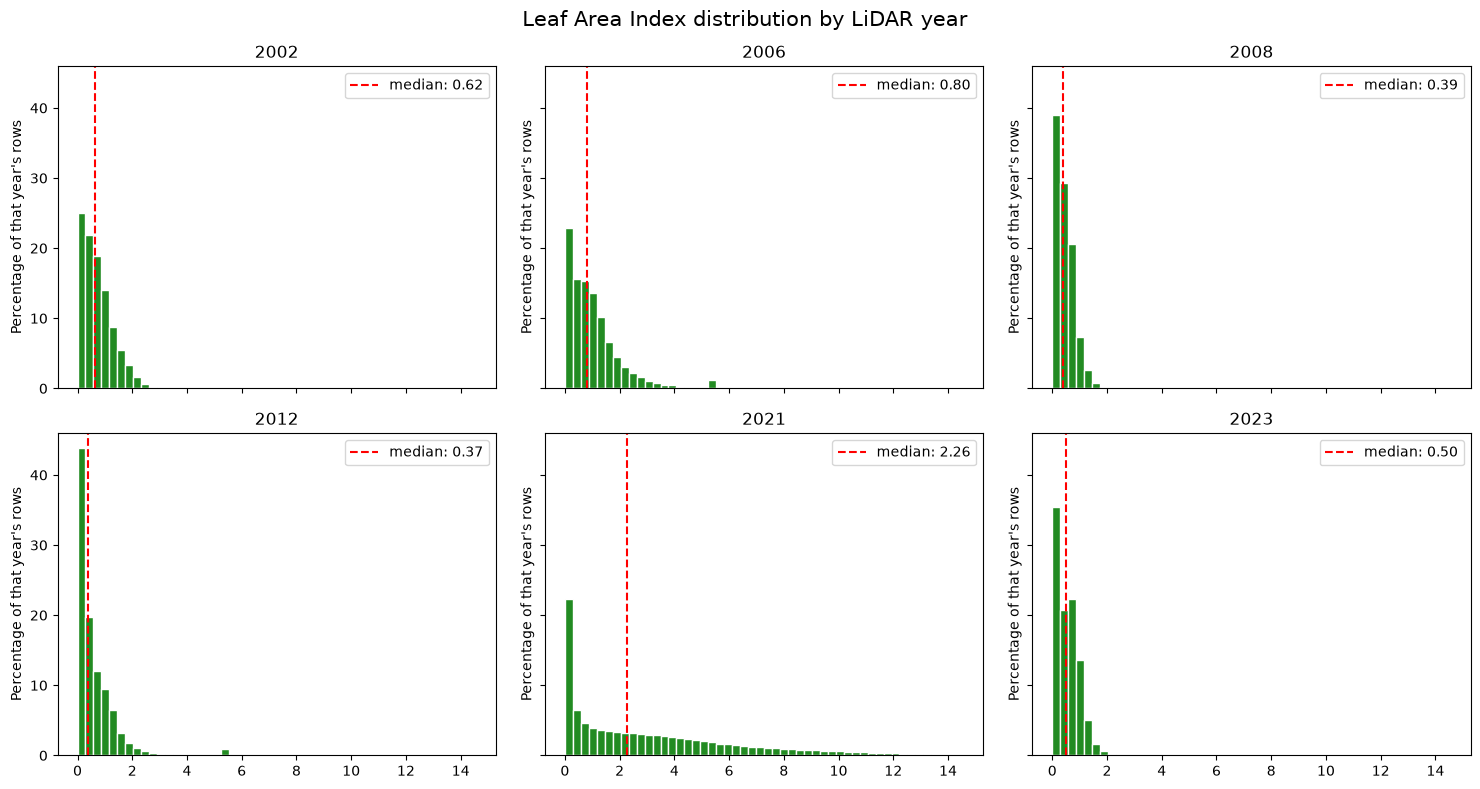

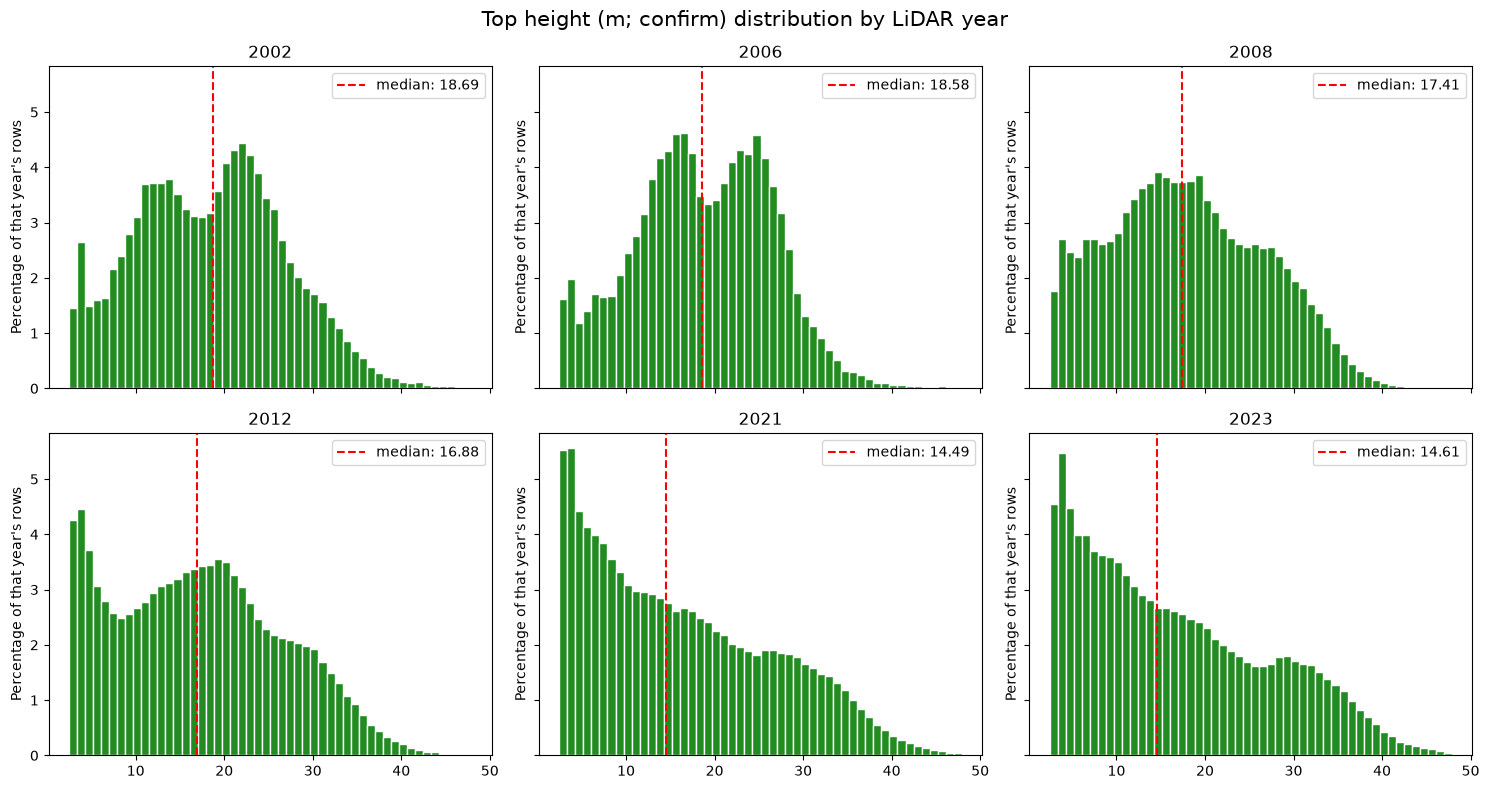

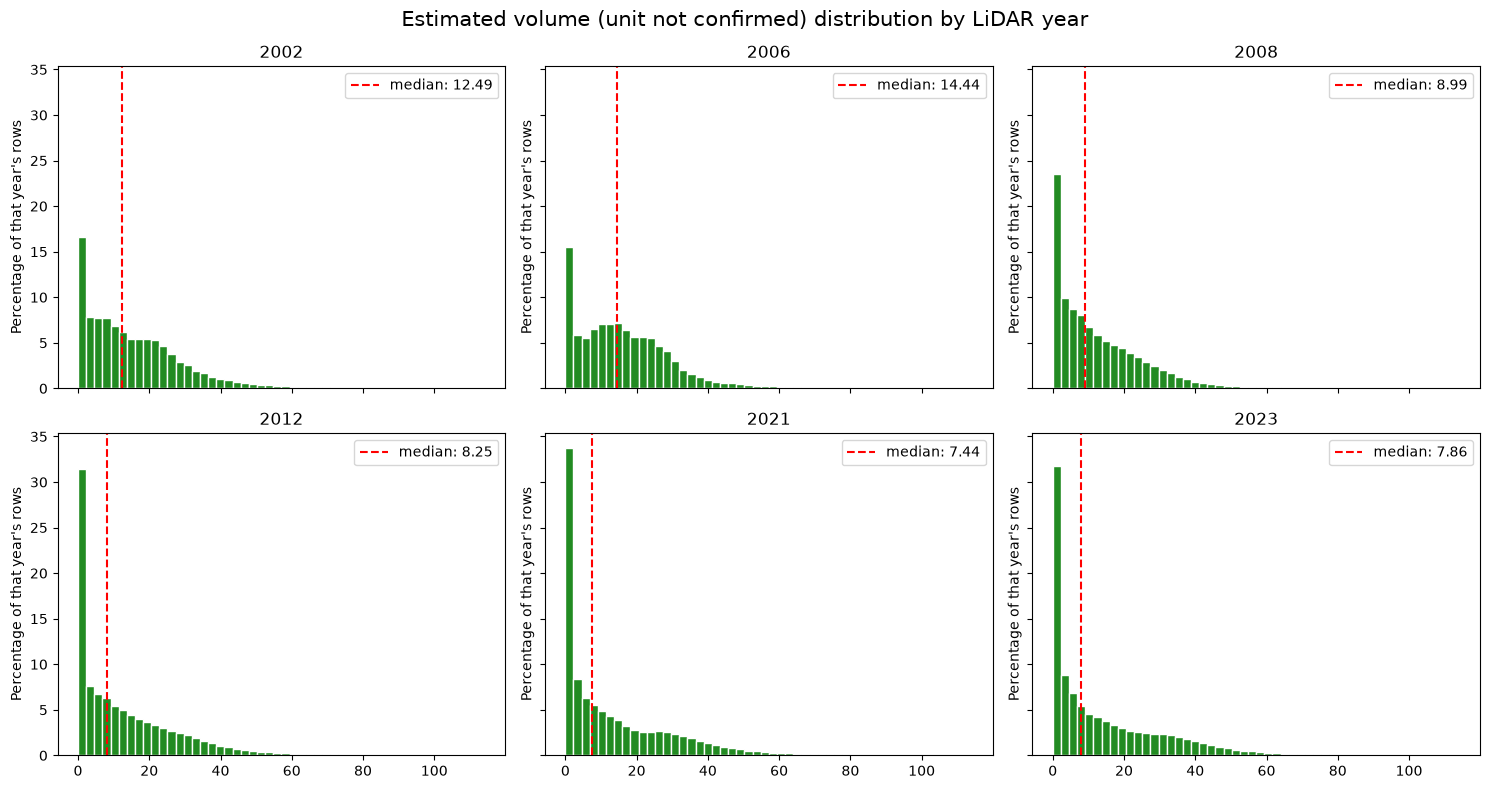

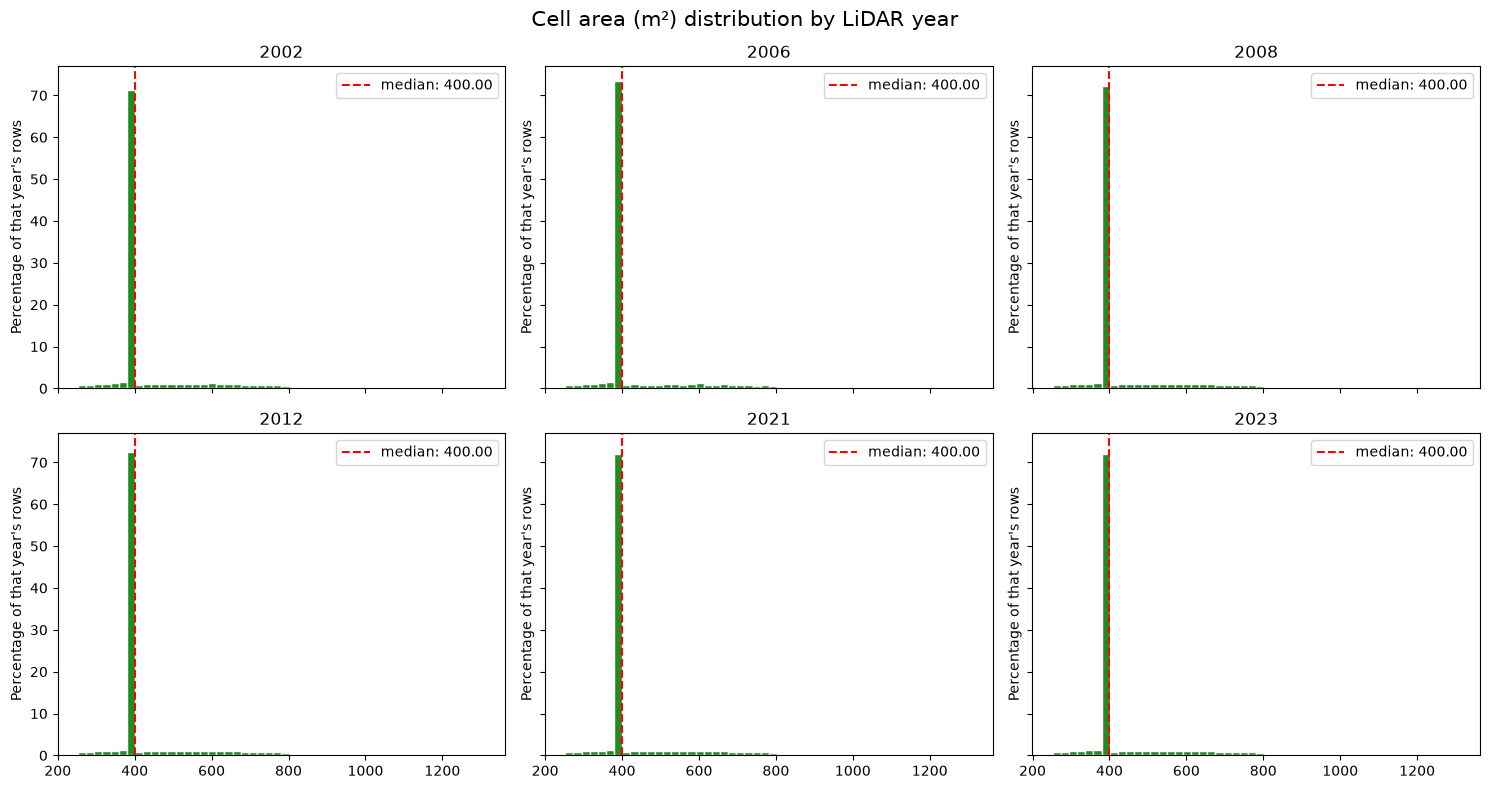

In [48]:
# Plot each numerical variable separately for all six survey years.
# Age is left out because many rows do not have a usable planting year.
histogram_variables = {
    "CanopyCover": "Canopy cover (proportion)",
    "LAI": "Leaf Area Index",
    "Top_Height": "Top height (m; confirm)",
    "Vol": "Estimated volume (unit not confirmed)",
    "area": "Cell area (m²)",
}

for variable, label in histogram_variables.items():
    all_values = attribute_table[variable].dropna()
    lower, upper = all_values.quantile([0.001, 0.999])
    common_bins = np.linspace(lower, upper, 51)
    fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)

    for (year, year_data), axis in zip(data_by_year.items(), axes.flat):
        values = year_data[variable].dropna()
        visible = values.loc[values.between(lower, upper)]
        weights = np.ones(len(visible)) * 100 / len(values)
        axis.hist(visible, bins=common_bins, weights=weights,
                  color="forestgreen", edgecolor="white")
        axis.axvline(values.median(), color="red", linestyle="--",
                     label=f"median: {values.median():.2f}")
        axis.set_title(str(year))
        axis.set_ylabel("Percentage of that year's rows")
        axis.legend()

    fig.suptitle(f"{label} distribution by LiDAR year", fontsize=15)
    plt.tight_layout()
    plt.show()

## 3.2 Bar charts for important categories

Each category receives six year-specific panels. Within each year, every `identification` is counted once. Species, yield class, and block are static 2025 attributes, so differences between years describe which plots were covered by each survey; they do not show attributes changing through time. Percentages are used because survey sizes differ.

In [ ]:
# Use the same category levels in all six panels.
one_row_per_plot = attribute_table.drop_duplicates("identification")
species_levels = (
    one_row_per_plot["spis"].fillna("Missing").value_counts().head(15).index
)
yield_class_levels = sorted(attribute_table["yldc"].unique())
block_levels = sorted(attribute_table["blk"].unique())

category_plots = {
    "spis": (species_levels, "Recorded species", "forestgreen"),
    "yldc": (yield_class_levels, "Yield class (m³ ha⁻¹ yr⁻¹)", "steelblue"),
    "blk": (block_levels, "SCDB block", "darkorange"),
}

for column, (levels, label, colour) in category_plots.items():
    fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)

    for (year, year_data), axis in zip(data_by_year.items(), axes.flat):
        plots_in_year = year_data.drop_duplicates("identification")
        values = plots_in_year[column]
        if column == "spis":
            values = values.fillna("Missing")
        percentages = (
            values.value_counts().reindex(levels, fill_value=0)
            / len(plots_in_year) * 100
        )
        percentages.plot.bar(ax=axis, color=colour)
        axis.set_title(str(year))
        axis.set_xlabel(label)
        axis.set_ylabel("Percentage of that year's plots")
        axis.tick_params(axis="x", labelrotation=90)

    fig.suptitle(f"{label} distribution by LiDAR year", fontsize=15)
    plt.tight_layout()
    plt.show()

## 3.3 Box plots and statistical outliers by survey year

Each measurement receives six year-specific box plots with a shared vertical scale. Individual outlier points are hidden to keep the boxes readable. The table then calculates separate 1.5 × IQR limits for every variable and year. Statistical outliers may be genuine forest conditions and are not automatically removed.

In [ ]:
# Compare four main measurements between survey years.
boxplot_variables = {
    "CanopyCover": "Canopy cover",
    "LAI": "Leaf Area Index",
    "Top_Height": "Top height",
    "Vol": "Estimated volume",
}

for variable, label in boxplot_variables.items():
    fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)
    for (year, year_data), axis in zip(data_by_year.items(), axes.flat):
        sns.boxplot(data=year_data, y=variable, showfliers=False,
                    color="lightgreen", ax=axis)
        axis.set_title(str(year))
        axis.set_xlabel("")
        axis.set_ylabel(label)
    fig.suptitle(f"{label} box plots by LiDAR year", fontsize=15)
    plt.tight_layout()
    plt.show()

# Count values outside the box-plot limits.
iqr_results = []
for year, year_data in data_by_year.items():
    for variable in boxplot_variables:
        q1, q3 = year_data[variable].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outside = ~year_data[variable].between(lower, upper)
        iqr_results.append({
            "LiDAR_year": year, "variable": variable,
            "lower_limit": lower, "upper_limit": upper,
            "rows_outside": outside.sum(),
            "percentage_outside": round(outside.mean() * 100, 2),
        })

iqr_outlier_summary = pd.DataFrame(iqr_results)
iqr_outlier_summary

## 3.4 Impossible, extreme, and capped values

Physical bounds, future dates, extreme measurements, and LAI capping are counted separately for all six years. The exact extreme-height and volume records are also returned for mapping or raw-LiDAR checking.

In [ ]:
# Count values that violate simple physical or coding rules in each year.
domain_checks_by_year = pd.DataFrame({
    year: {
        "CanopyCover outside 0 to 1": (~d["CanopyCover"].between(0, 1)).sum(),
        "GapFraction outside 0 to 1": (~d["GapFraction"].between(0, 1)).sum(),
        "negative LAI": d["LAI"].lt(0).sum(),
        "Top_Height at or below zero": d["Top_Height"].le(0).sum(),
        "area at or below zero": d["area"].le(0).sum(),
        "planting year after 2025": d["plyr"].gt(2025).sum(),
        "last thinning after 2025": d["last_thinn"].gt(2025).sum(),
        "Top_Height above 150 m": d["Top_Height"].gt(150).sum(),
        "Vol above 1000": d["Vol"].gt(1000).sum(),
    }
    for year, d in data_by_year.items()
}).T

# Check whether LAI piles up at 5.5 or extends beyond it.
lai_cap_summary = (
    attribute_table.assign(
        LAI_at_5_5=np.isclose(attribute_table["LAI"], 5.5),
        LAI_above_5_5=attribute_table["LAI"].gt(5.5),
    )
    .groupby("LiDAR_year")
    .agg(
        rows=("LAI", "size"),
        rows_at_5_5=("LAI_at_5_5", "sum"),
        rows_above_5_5=("LAI_above_5_5", "sum"),
        maximum_LAI=("LAI", "max"),
    )
)

extreme_measurement_rows = (
    attribute_table.loc[
        attribute_table["Top_Height"].gt(150) | attribute_table["Vol"].gt(1000),
        ["identification", "LiDAR_year", "display_id", "spis",
         "CanopyCover", "LAI", "Top_Height", "Vol"],
    ]
    .sort_values(["identification", "LiDAR_year"])
)

display(domain_checks_by_year)
display(lai_cap_summary)
extreme_measurement_rows

## Section 3 interpretation

**Observed results:**

- Canopy cover and gap fraction stay within 0–1, and there are no negative LAI, non-positive heights, or non-positive areas.
- LAI is capped at 5.5 in 2002, 2006, 2008, 2012, and 2023. In 2021, 64,355 rows exceed 5.5 and the maximum is 23.03, confirming a processing difference.
- There are 252 rows with `plyr = 2026` and 2,862 rows with `last_thinn = 2026`. These occur in the 2025 sub-compartment attributes and require interpretation as future/planned or incorrectly coded dates.
- The nine extreme-height rows include all five volumes above 1,000. Their IDs are displayed for later spatial inspection.

All observations were evaluated, but none of the Section 3 results pool different survey years. The main questions are whether a between-year difference is ecological or caused by survey processing; whether category imbalance reflects survey coverage; whether extremes are isolated, spatially clustered, or repeated through time; and whether spikes indicate caps or rounding.

Unequal cell areas may also require area-weighted forest summaries. Finally, all important plots should be repeated for the final older Sitka spruce cohort because the full dataset contains several species, stand ages, coverage patterns, and pre-planting scans. No records are removed here.